# Portfolio Optimisation Using CVXPY & PCA Risk Model

This script illustrates one way that CVXPY could be used on more complex portfolio optimisation problems. (i.e. constraints & risk targets where risk is calculated with a statistical risk model).

The theory is that there are a few risk drivers that explain most of the daily returns. In this case, I've used Principal Component Analysis to find the two key principal components that explain most of the daily returns. 

Once I've found these, a stock's expected move is beta1 * ret(PC1) + beta2 * ret(PC2) + residual.

The portfolio expected risk is: $ \sqrt{w^{T}(BPB^{T} + S)w} $ 

where:
- $ w $ is the portfolio weights
- $ B $ is the PC betas
- $ P $ is the PC covariance matrix
- $ S $ is the idiosyncratic variance matrix

To summarise, I:
- Import data (cell 73-76),
- Perform PCA (cell 77),
- calculate betas of the ETFs to the PC returns (cell 78), 
- calculate the PC returns (cell 79), 
- calculate the sample covariance matrix of the PCs (cell 80), 
- calculate an unexplained variance per ETF (cell 81,82), and 
- Combine the above to predict portfolio risk which I then feed into an optimiser (cells83,84 )



#### Import Packages

In [72]:
import pandas as pd
pd.options.display.float_format = '{:,.2f}%'.format
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import cvxpy as cp
import os

#### Import Data

In [73]:
tickers = ("HYG","TLT","TIP","LQD","EMB","BWX")

In [74]:
data_path = "C:/Users/User/My Drive/Finance/Quant/CVXOpt_Demo/Data.csv"
if os.path.exists(data_path):
    prices = pd.read_csv(data_path,
                         index_col = 0,
                         parse_dates = True)
else:
    for ticker in tickers:
        instrument = yf.Ticker(ticker)
        data = instrument.history(period = "max")
        temp = pd.DataFrame(data["Close"].values,
                            data.index,
                            [ticker])
        if ticker == tickers[0]:
            prices = temp.copy(deep = True)
        else:
            prices = prices.join(temp, how = "outer") 
        last_quote = data['Close'].iloc[-1]
        print(ticker, last_quote)
    prices.to_csv(data_path)

#### Check data (use .tail() to see the last 5 rows of data)

In [75]:
returns = prices.pct_change()
returns.dropna(inplace = True)
returns.tail()

,HYG,TLT,TIP,LQD,EMB,BWX
Date,,,,,,
2022-12-28,-0.01%,-0.01%,-0.00%,-0.00%,-0.00%,-0.01%
2022-12-29,0.01%,0.01%,0.00%,0.01%,0.01%,0.02%
2022-12-30,0.00%,-0.01%,-0.00%,-0.01%,-0.00%,-0.01%
2023-01-03,0.00%,0.02%,0.00%,0.01%,0.00%,-0.00%
2023-01-04,0.01%,0.01%,0.00%,0.01%,0.01%,0.01%


#### Plot points in return-risk space

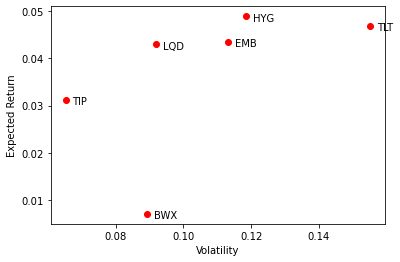

In [76]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
n = len(mu)
for i in range(n):
    plt.plot(cp.sqrt(Sigma.values[i, i]).value, mu[i], "ro")
    ax.annotate(
        mu.index[i],
        xy=(cp.sqrt(Sigma.values[i, i]).value+0.002, mu[i]-0.001),
    )

plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.show()

#### Fit PCA and check proportion of variance explained by each PC 

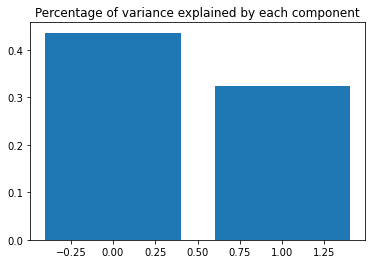

In [77]:
from sklearn.decomposition import PCA

def fit_pca(returns, num_PC_exposures, svd_solver):
    """
    Fit PCA model with returns.

    Parameters
    ----------
    returns : DataFrame
        Returns for each ticker and date
    num_PC_exposures : int
        Number of PCs for PCA
    svd_solver: str
        The solver to use for the PCA model

    Returns
    -------
    pca : PCA
        Model fit to returns
    """
    pca = PCA(n_components = num_PC_exposures, svd_solver = svd_solver)
    pca.fit(returns)
    return pca

num_PC_exposures = 2
pca = fit_pca(returns, num_PC_exposures, 'full')
plt.bar(np.arange(num_PC_exposures), pca.explained_variance_ratio_);
plt.title("Percentage of variance explained by each component")
plt.show()

#### Calculate betas of ETFs to PCs

In [78]:
def PC_betas(pca, PC_beta_indices, PC_beta_columns):
    """
    Get the PC betas from the PCA model.

    Parameters
    ----------
    pca : PCA
        Model fit to returns
    PC_beta_indices : 1 dimensional Ndarray
        PC beta indices
    PC_beta_columns : 1 dimensional Ndarray
        PC beta columns

    Returns
    -------
    PC_betas : DataFrame
        PC betas
    """
    assert len(PC_beta_indices.shape) == 1
    assert len(PC_beta_columns.shape) == 1
    return pd.DataFrame(pca.components_.T,
                        PC_beta_indices,
                        PC_beta_columns)

risk_model = {}
risk_model['PC_betas'] = PC_betas(pca, returns.columns.values, 
                                          np.arange(num_PC_exposures))
risk_model['PC_betas'].tail()

,0,1
TLT,-0.79%,-0.41%
TIP,-0.29%,-0.02%
LQD,-0.38%,0.22%
EMB,-0.27%,0.52%
BWX,-0.26%,0.19%


#### Plot returns of PCs

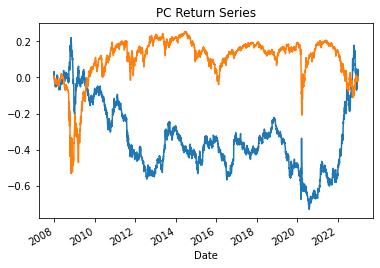

In [79]:
def PC_returns(pca, 
                   returns, 
                   PC_return_indices, 
                   PC_return_columns):
    """
    Get the PC returns from the PCA model.

    Parameters
    ----------
    pca : PCA
        Model fit to returns
    returns : DataFrame
        Returns for each ticker and date
    PC_return_indices : 1 dimensional Ndarray
        PC return indices
    PC_return_columns : 1 dimensional Ndarray
        PC return columns

    Returns
    -------
    PC_returns : DataFrame
        PC returns
    """
    assert len(PC_return_indices.shape) == 1
    assert len(PC_return_columns.shape) == 1
    return pd.DataFrame(pca.transform(returns.values),
                        PC_return_indices,
                        PC_return_columns)


risk_model['PC_returns'] = PC_returns(
    pca,
    returns,
    returns.index,
    np.arange(num_PC_exposures))

risk_model['PC_returns'].cumsum().plot(legend=None);
plt.title("PC Return Series")
ann_PC = 252

#### Calculate covariance matrix of PCs

In [80]:
def PC_cov_matrix(PC_returns, ann_PC):
    """
    Get the PC covariance matrix

    Parameters
    ----------
    PC_returns : DataFrame
        PC returns
    ann_PC : int
        Annualization PC

    Returns
    -------
    PC_cov_matrix : DataFrame
        PC covariance matrix
    """
    return np.diag(PC_returns.var(axis=0,ddof=1)*ann_PC)

risk_model['PC_cov_matrix'] = pd.DataFrame(PC_cov_matrix(risk_model['PC_returns'], 
                                                                 ann_PC))
risk_model['PC_cov_matrix']

,0,1
0,0.03%,0.00%
1,0.00%,0.02%


#### Calculate idiosyncratic variance for each instrument (variance not explained by relationship to PCs)

In [81]:
def idiosyncratic_var_matrix(returns, PC_returns, PC_betas, ann_PC):
    """
    Get the idiosyncratic variance matrix

    Parameters
    ----------
    returns : DataFrame
        Returns for each ticker and date
    PC_returns : DataFrame
        PC returns
    PC_betas : DataFrame
        PC betas
    ann_PC : int
        Annualization PC

    Returns
    -------
    idiosyncratic_var_matrix : DataFrame
        Idiosyncratic variance matrix
    """
    common_returns_=pd.DataFrame(np.dot(PC_returns,PC_betas.T),
                                 returns.index,
                                 returns.columns)
    
    residuals_=returns-common_returns_
    return pd.DataFrame(np.diag(np.var(residuals_))*ann_PC,
                        returns.columns,
                        returns.columns)

risk_model['idiosyncratic_var_matrix'] = idiosyncratic_var_matrix(returns, 
                                                                  risk_model['PC_returns'], 
                                                                  risk_model['PC_betas'], 
                                                                  ann_PC)
risk_model['idiosyncratic_var_matrix']

,HYG,TLT,TIP,LQD,EMB,BWX
HYG,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
TLT,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
TIP,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
LQD,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
EMB,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
BWX,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


In [82]:
def idiosyncratic_var_vector(returns, idiosyncratic_var_matrix):
    """
    Get the idiosyncratic variance vector

    Parameters
    ----------
    returns : DataFrame
        Returns for each ticker and date
    idiosyncratic_var_matrix : DataFrame
        Idiosyncratic variance matrix

    Returns
    -------
    idiosyncratic_var_vector : DataFrame
        Idiosyncratic variance Vector
    """
    return pd.DataFrame(np.diagonal(idiosyncratic_var_matrix), returns.columns)

risk_model['idiosyncratic_var_vector'] = idiosyncratic_var_vector(returns, 
                                                                  risk_model['idiosyncratic_var_matrix'])
risk_model['idiosyncratic_var_vector']

,0
HYG,0.00%
TLT,0.00%
TIP,0.00%
LQD,0.00%
EMB,0.00%
BWX,0.00%


#### Create optimiser that maximises return subject to risk constraints, weight constraints, factor exposure constraints

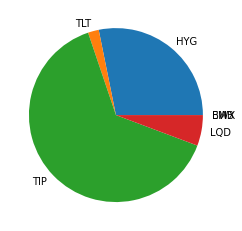

In [83]:
from abc import ABC, abstractmethod

class AbstractOptimalHoldings(ABC):    
    @abstractmethod
    def _get_obj(self, weights, expected_return):
        """
        Get the objective function

        Parameters
        ----------
        weights : CVXPY Variable
            Portfolio weights
        expected_return : DataFrame
            Alpha vector

        Returns
        -------
        objective : CVXPY Objective
            Objective function
        """
        
        raise NotImplementedError()
    
    @abstractmethod
    def _get_constraints(self, weights, PC_betas, risk):
        """
        Get the constraints

        Parameters
        ----------
        weights : CVXPY Variable
            Portfolio weights
        PC_betas : 2 dimensional Ndarray
            PC betas
        risk: CVXPY Atom
            Predicted variance of the portfolio returns

        Returns
        -------
        constraints : List of CVXPY Constraint
            Constraints
        """
        
        raise NotImplementedError()
        
    def _get_risk(self, weights, PC_betas, expected_return_index, 
                  PC_cov_matrix, 
                  idiosyncratic_var_vector):
        f = PC_betas.loc[expected_return_index].values.T @ weights
        X = PC_cov_matrix
        S = np.diag(idiosyncratic_var_vector.loc[expected_return_index].values.flatten())

        return cp.quad_form(f, X) + cp.quad_form(weights, S)
    
    def find(self, expected_return, PC_betas, PC_cov_matrix, idiosyncratic_var_vector):
        weights = cp.Variable(len(expected_return))
        risk = self._get_risk(weights, PC_betas, expected_return.index, PC_cov_matrix, idiosyncratic_var_vector)
        
        obj = self._get_obj(weights, expected_return)
        constraints = self._get_constraints(weights, PC_betas.loc[expected_return.index].values, risk)
        
        prob = cp.Problem(obj, constraints)
        prob.solve(max_iters=500)

        optimal_weights = np.asarray(weights.value).flatten()
        return pd.DataFrame(data=optimal_weights, index=expected_return.index)

class OptimalHoldings(AbstractOptimalHoldings):
    def _get_obj(self, weights, expected_return):
        """
        Get the objective function

        Parameters
        ----------
        weights : CVXPY Variable
            Portfolio weights
        expected_return : DataFrame
            Alpha vector

        Returns
        -------
        objective : CVXPY Objective
            Objective function
        """
        assert(len(expected_return.columns) == 1)
        
        return cp.Minimize(-expected_return.T.values[0]@weights)
    
    def _get_constraints(self, weights, PC_betas, risk):
        """
        Get the constraints

        Parameters
        ----------
        weights : CVXPY Variable
            Portfolio weights
        PC_betas : 2 dimensional Ndarray
            PC betas
        risk: CVXPY Atom
            Predicted variance of the portfolio returns

        Returns
        -------
        constraints : List of CVXPY Constraint
            Constraints
        """
        assert(len(PC_betas.shape) == 2)
        
        return [risk<=self.risk_cap**2,
                PC_betas.T@weights<=self.PC_max,
                PC_betas.T@weights>=self.PC_min,
                sum(weights)==1,
                weights>=self.weights_min,
                weights<=self.weights_max]

    def __init__(self, risk_cap=0.12, 
                 PC_max=10.0, 
                 PC_min=-10.0, 
                 weights_max=1,
                 weights_min=0):
        self.risk_cap=risk_cap
        self.PC_max=PC_max
        self.PC_min=PC_min
        self.weights_max=weights_max
        self.weights_min=weights_min


optimal_weights = OptimalHoldings(risk_cap=0.06, 
                                PC_max=10.0, 
                                PC_min=-10.0, 
                                weights_max=1,
                                weights_min=0).find(pd.DataFrame(mu),
                                                        risk_model['PC_betas'], 
                                                        risk_model['PC_cov_matrix'], 
                                                        risk_model['idiosyncratic_var_vector']
                                                        )
plt.pie(np.concatenate(optimal_weights.values), labels = optimal_weights.index, normalize = True);

#### Calculate allocation that maximises return for each risk target level

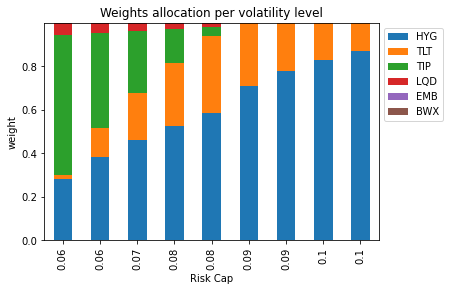

In [84]:
weights_ef = np.zeros((0,len(mu)))
risk_range = np.arange(0.06,0.105,0.005)
for risk in risk_range:
    optimal_weights = OptimalHoldings(risk_cap=risk, 
                                    PC_max=10.0, 
                                    PC_min=-10.0, 
                                    weights_max=1,
                                    weights_min=0).find(pd.DataFrame(mu),
                                                            risk_model['PC_betas'], 
                                                            risk_model['PC_cov_matrix'], 
                                                            risk_model['idiosyncratic_var_vector']
                                                            )
    weights_ef = np.vstack((weights_ef, optimal_weights.values.T))

weights_df = pd.DataFrame(weights_ef, 
                          columns=mu.index, 
                          index=np.round(risk_range,2))
ax = weights_df.plot(kind='bar', stacked=True) 
ax.set(title='Weights allocation per volatility level',
       xlabel='Risk Cap', 
       ylabel='weight')
ax.legend(bbox_to_anchor=(1,1));